In [1]:
# !pip install -r requirements.txt -qq

In [1]:
# import sys
# sys.path.append('/home/rishabhtiwari/prm-inference')

In [1]:
import torch
from transformers import AutoTokenizer

from constants.model_constants import MODEL_CLASS_MAP
from utils.io_utils import prepare_input, derive_step_rewards

[2025-11-19 23:19:51,104] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/rishabhtiwari/anaconda3/envs/prm_bias/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/rishabhtiwari/anaconda3/envs/prm_bias/compiler_compat/ld: warning: librt.so.1, needed by /usr/local/cuda/lib64/libcufile.so, not found (try using -rpath or -rpath-link)
/home/rishabhtiwari/anaconda3/envs/prm_bias/compiler_compat/ld: warning: libpthread.so.0, needed by /usr/local/cuda/lib64/libcufile.so, not found (try using -rpath or -rpath-link)
/home/rishabhtiwari/anaconda3/envs/prm_bias/compiler_compat/ld: warning: libstdc++.so.6, needed by /usr/local/cuda/lib64/libcufile.so, not found (try using -rpath or -rpath-link)
/home/rishabhtiwari/anaconda3/envs/prm_bias/compiler_compat/ld: warning: libm.so.6, needed by /usr/local/cuda/lib64/libcufile.so, not found (try using -rpath or -rpath-link)
/home/rishabhtiwari/anaconda3/envs/prm_bias/compiler_compat/ld: /usr/local/cuda/lib64/libcufile.so: undefined reference to `std::runtime_err

In [2]:
def calculate_reward(model_path, problem, steps):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    model = MODEL_CLASS_MAP[model_path].from_pretrained(model_path, device_map="auto", torch_dtype=torch.float16)
    model = model.eval()
    input_ids, token_masks = prepare_input(
                            model_path, 
                            problem=problem, 
                            steps=steps, 
                            tokenizer=tokenizer
                        )
    with torch.inference_mode():
        logits = model(input_ids).logits

    rewards = derive_step_rewards(
        model_path, 
        logits, 
        token_masks, 
        tokenizer
    )
    return rewards

### Loading Dataset

In [3]:
from datasets import load_dataset

# Load the AIME 2025 dataset from Hugging Face
aime_2025_dataset = load_dataset("opencompass/AIME2025", "AIME2025-I", split="test")
aime_2025_data = aime_2025_dataset[:]

In [4]:
idx = 1
aime_2025_data['question'][idx], aime_2025_data['answer'][idx]

('On $\\triangle ABC$ points $A,D,E$, and $B$ lie that order on side $\\overline{AB}$ with $AD=4, DE=16$, and $EB=8$. Points $A,F,G$, and $C$ lie in that order on side $\\overline{AC}$ with $AF=13, FG=52$, and $GC=26$. Let $M$ be the reflection of $D$ through $F$, and let $N$ be the reflection of $G$ through $E$. Quadrilateral $DEGF$ has area 288. Find the area of heptagon $AFNBCEM$.',
 '588')

In [ ]:
SKYWORK_MODEL_PATH = "/home/rishabhtiwari/hf_cache/Skywork--Skywork-o1-Open-PRM-Qwen-2.5-1.5B"
data = {
    # "problem": "Cindy's math and science books weigh 2 pounds each. Her French book weighs 4 pounds and her English book weighs 3 pounds. Her history book weighs twice as much as her English book. If Cindy carries all of her books at once, what will be the total weight of the books she is carrying?",
    "problem": "On $\\triangle ABC$ points $A,D,E$, and $B$ lie that order on side $\\overline{AB}$ with $AD=4, DE=16$, and $EB=8$. Points $A,F,G$, and $C$ lie in that order on side $\\overline{AC}$ with $AF=13, FG=52$, and $GC=26$. Let $M$ be the reflection of $D$ through $F$, and let $N$ be the reflection of $G$ through $E$. Quadrilateral $DEGF$ has area 288. Find the area of heptagon $AFNBCEM$.",
    "steps": [
        "To determine the total weight of all Cindy's books, we need to calculate the weight of each book individually and then sum these weights.", 
        "First, for the math and science books:\n- Each math book weighs 2 pounds.\n- Each science book weighs 2 pounds.\n- Cindy has 2 math books and 2 science books.\n- Total weight of math books: \\(2 \\text{ books} \\times 2 \\text{ pounds/book} = 4 \\text{ pounds}\\).\n- Total weight of science books: \\(2 \\text{ books} \\times 2 \\text{ pounds/book} = 4 \\text{ pounds}\\).\n- Combined weight of math and science books: \\(4 \\text{ pounds} + 4 \\text{ pounds} = 8 \\text{ pounds}\\).", 
        "Second, for the French book:\n- The French book weighs 4 pounds.",
        "Third, for the English book:\n- The English book weighs 3 pounds.", 
        "Fourth, for the history book:\n- The history book weighs twice as much as the English book.\n- Weight of the history book: \\(2 \\times 3 \\text{ pounds} = 6 \\text{ pounds}\\).",
        "Finally, for the total weight:\n- Sum of the weights of all the books: \\[ 8 \\text{ pounds} \\text{ (math and science)} + 4 \\text{ pounds} \\text{ (French)} + 3 \\text{ pounds} \\text{ (English)} + 6 \\text{ pounds} \\text{ (history)} = 21 \\text{ pounds} \\]",
        "Therefore, the total weight of the books Cindy is carrying is \\(\\boxed{21}\\) pounds."
    ],
    # "answer": "17"
    "answer": "588"

}

In [6]:
# from transformers import AutoModelForCausalLM
# import torch

# model_path = "/home/rishabhtiwari/hf_cache/Skywork--Skywork-o1-Open-PRM-Qwen-2.5-1.5B"

# # Load the model
# print("Loading model...")
# model = MODEL_CLASS_MAP[SKYWORK_MODEL_PATH].from_pretrained(
#     model_path,
#     torch_dtype=torch.bfloat16,
#     device_map="cpu"  # Keep on CPU for conversion
# )

# # Save with safetensors format
# print("Saving in safetensors format...")
# model.save_pretrained(
#     model_path,
#     safe_serialization=True  # This enables safetensors format
# )

# print("Conversion complete!")

In [7]:
tokenizer = AutoTokenizer.from_pretrained(SKYWORK_MODEL_PATH)
    
model = MODEL_CLASS_MAP[SKYWORK_MODEL_PATH].from_pretrained(
    SKYWORK_MODEL_PATH, 
    torch_dtype=torch.bfloat16,
    device_map={"": "cuda:0"},  # Load directly to cuda:5
    low_cpu_mem_usage=False 
)
print('done')
model = model.eval()
input_ids, token_masks = prepare_input(
                        SKYWORK_MODEL_PATH, 
                        problem=data["problem"], 
                        steps=data["steps"], 
                        tokenizer=tokenizer,
                        device=torch.device("cuda:0")
                    )


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of the model checkpoint at /home/rishabhtiwari/hf_cache/Skywork--Skywork-o1-Open-PRM-Qwen-2.5-1.5B were not used when initializing Qwen2ForCausalLM: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing Qwen2ForCausalLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Qwen2ForCausalLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/home/rishabhtiwari/prm-attack/utils/models/skywork_o1_open_prm/modeling_base.py:264: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during

done


In [8]:
tokenizer.decode(input_ids[-1])

'\n'

In [9]:
with torch.inference_mode():
    logits = model(input_ids.view(1, -1))[-1]

rewards = derive_step_rewards(
    SKYWORK_MODEL_PATH, 
    logits, 
    token_masks, 
    tokenizer
)
print(rewards)
# Rewards should be close to: [[0.9304260015487671, 0.5120438933372498, 0.6100339889526367, 0.5191707015037537, 0.57666015625, 0.787788450717926, 0.8843944668769836]]

[[0.04739352688193321, 0.04780266061425209, 0.07665631175041199, 0.09360786527395248, 0.08396022021770477, 0.06767538189888, 0.07616749405860901]]


In [10]:
from vllm import LLM, SamplingParams

# Load Qwen2.5-Math-7B model using vLLM
llm = LLM(
    model="Qwen/Qwen2.5-Math-7B-Instruct",
    tensor_parallel_size=1,
    gpu_memory_utilization=0.9,
    trust_remote_code=True,
    device="cuda:1"
)



INFO 11-18 00:18:41 __init__.py:207] Automatically detected platform cuda.
INFO 11-18 00:18:41 __init__.py:30] Available plugins for group vllm.general_plugins:
INFO 11-18 00:18:41 __init__.py:32] name=register_dummy_model, value=vllm_add_dummy_model.prm_model:register
INFO 11-18 00:18:41 __init__.py:34] all available plugins for group vllm.general_plugins will be loaded.
INFO 11-18 00:18:41 __init__.py:36] set environment variable VLLM_PLUGINS to control which plugins to load.
INFO 11-18 00:18:41 __init__.py:44] plugin register_dummy_model loaded.
INFO 11-18 00:18:48 config.py:549] This model supports multiple tasks: {'classify', 'embed', 'score', 'reward', 'generate'}. Defaulting to 'generate'.
INFO 11-18 00:18:48 llm_engine.py:234] Initializing a V0 LLM engine (v0.7.3) with config: model='Qwen/Qwen2.5-Math-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, token

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 11-18 00:18:53 model_runner.py:1115] Loading model weights took 14.2419 GB
INFO 11-18 00:18:54 worker.py:267] Memory profiling takes 0.66 seconds
INFO 11-18 00:18:54 worker.py:267] the current vLLM instance can use total_gpu_memory (79.25GiB) x gpu_memory_utilization (0.90) = 71.33GiB
INFO 11-18 00:18:54 worker.py:267] model weights take 14.24GiB; non_torch_memory takes 0.09GiB; PyTorch activation peak memory takes 1.42GiB; the rest of the memory reserved for KV Cache is 55.58GiB.
INFO 11-18 00:18:54 executor_base.py:111] # cuda blocks: 65040, # CPU blocks: 4681
INFO 11-18 00:18:54 executor_base.py:116] Maximum concurrency for 4096 tokens per request: 254.06x
INFO 11-18 00:18:56 model_runner.py:1434] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI. If out-of-memory error occurs during cudagraph capture, consider decreasing `gpu_memory

Capturing CUDA graph shapes: 100%|██████████| 35/35 [00:12<00:00,  2.77it/s]

INFO 11-18 00:19:09 model_runner.py:1562] Graph capturing finished in 13 secs, took 0.20 GiB
INFO 11-18 00:19:09 llm_engine.py:436] init engine (profile, create kv cache, warmup model) took 16.10 seconds


In [11]:
# Set up sampling parameters for generation
sampling_params = SamplingParams(
    temperature=0.6,
    top_p=0.95,
    max_tokens=2048,
    n=100  # Generate 100 answers
)

# Format the problem as a prompt with step-by-step instructions
prompt = f"""Problem: {data['problem']}

Please solve this problem step by step. Separate each step with a blank line (\\n\\n). Provide your final answer in \\boxed{{}}.

Solution:"""

# Generate 100 answers
outputs = llm.generate([prompt], sampling_params)

# Extract the generated texts
generated_answers = [output.text for output in outputs[0].outputs]

print(f"Generated {len(generated_answers)} answers")
for i, answer in enumerate(generated_answers[:3]):  # Print first 3 as examples
    print(f"\n--- Answer {i+1} ---")
    print(answer)


Processed prompts:   0%|          | 0/100 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   1%|          | 1/100 [00:44<1:13:30, 44.55s/it, est. speed input: 3.91 toks/s, output: 3265.32 toks/s]

Generated 100 answers

--- Answer 1 ---
 We start by determining the coordinates of the points on triangle \(ABC\). Let \(A = (0, 0)\), \(B = (28, 0)\), and \(C = (x, y)\). The points \(D\), \(E\), and \(F\), \(G\) are located as follows:
- \(D = (4, 0)\)
- \(E = (20, 0)\)
- \(F = (13, 0)\)
- \(G = (69, 0)\)

Next, we find the coordinates of the reflections \(M\) and \(N\):
- \(M\) is the reflection of \(D\) through \(F\). Since \(F\) is at \((13, 0)\), the midpoint of \(DM\) is \(F\). Therefore, \(M = (2 \cdot 13 - 4, 0) = (22, 0)\).
- \(N\) is the reflection of \(G\) through \(E\). Since \(E\) is at \((20, 0)\), the midpoint of \(GN\) is \(E\). Therefore, \(N = (2 \cdot 20 - 69, 0) = (-29, 0)\).

Now, we need to find the area of quadrilateral \(DEGF\). The vertices of \(DEGF\) are \((20, 0)\), \((22, 0)\), \((69, 0)\), and \((13, 0)\). Since these points all lie on the x-axis, the area of quadrilateral \(DEGF\) is zero. However, we are given that the area of quadrilateral \(DEGF\) is

In [12]:
import re

def extract_boxed_answer(text):
    """Extract the answer from \\boxed{} notation"""
    match = re.search(r'\\boxed\{([^}]+)\}', text)
    if match:
        return match.group(1).strip()
    return None

def normalize_answer(answer):
    """Normalize answer for comparison"""
    if answer is None:
        return None
    # Remove spaces and convert to lowercase
    answer = answer.replace(' ', '').lower()
    # Remove common formatting
    answer = answer.replace(',', '')
    return answer

# Extract ground truth answer
ground_truth = data['answer']#extract_boxed_answer(data['answer'])
ground_truth_normalized = normalize_answer(ground_truth)

print(f"Ground truth answer: {ground_truth}")

# Extract predicted answers and check correctness
predicted_answers = []
correctness = []

for i, answer in enumerate(generated_answers):
    predicted = extract_boxed_answer(answer)
    predicted_normalized = normalize_answer(predicted)
    
    is_correct = 1 if predicted_normalized == ground_truth_normalized else 0
    
    predicted_answers.append(predicted)
    correctness.append(is_correct)
    
    print(f"Answer {i+1}: {predicted} -> {'Correct' if is_correct else 'Incorrect'}")

print(f"\nCorrectness list: {correctness}")
print(f"Accuracy: {sum(correctness)}/{len(correctness)} = {sum(correctness)/len(correctness):.2%}")


Ground truth answer: 588
Answer 1: 768 -> Incorrect
Answer 2: 870 -> Incorrect
Answer 3: 504 -> Incorrect
Answer 4: 576 -> Incorrect
Answer 5: None -> Incorrect
Answer 6: 594 -> Incorrect
Answer 7: 758 -> Incorrect
Answer 8: 1941.5 -> Incorrect
Answer 9: None -> Incorrect
Answer 10: 44853 -> Incorrect
Answer 11: 720 -> Incorrect
Answer 12: 96 -> Incorrect
Answer 13: 576 -> Incorrect
Answer 14: None -> Incorrect
Answer 15: None -> Incorrect
Answer 16: 827 -> Incorrect
Answer 17: 672 -> Incorrect
Answer 18: 445 -> Incorrect
Answer 19: 648 -> Incorrect
Answer 20: None -> Incorrect
Answer 21: None -> Incorrect
Answer 22: 4428 -> Incorrect
Answer 23: 199 -> Incorrect
Answer 24: 864 -> Incorrect
Answer 25: None -> Incorrect
Answer 26: None -> Incorrect
Answer 27: 597 -> Incorrect
Answer 28: 1248 -> Incorrect
Answer 29: 1644 -> Incorrect
Answer 30: 491 -> Incorrect
Answer 31: 864 -> Incorrect
Answer 32: 588 -> Correct
Answer 33: 3456 -> Incorrect
Answer 34: 648 -> Incorrect
Answer 35: None ->

In [13]:
def parse_steps_from_generation(text):
    """
    Parse a generated text into individual steps.
    Steps are separated by double newlines (\\n\\n).
    """
    # Split by double newlines to get steps
    steps = [step.strip() for step in text.split('\n\n') if step.strip()]
    return steps

# Parse all generated answers into steps
parsed_generations = []
for i, answer in enumerate(generated_answers):
    steps = parse_steps_from_generation(answer)
    parsed_generations.append(steps)
    print(f"\nGeneration {i+1} has {len(steps)} steps")
    for j, step in enumerate(steps[:3]):  # Print first 3 steps as example
        print(f"  Step {j+1}: {step[:100]}...")  # Print first 100 chars



Generation 1 has 6 steps
  Step 1: We start by determining the coordinates of the points on triangle \(ABC\). Let \(A = (0, 0)\), \(B =...
  Step 2: Next, we find the coordinates of the reflections \(M\) and \(N\):
- \(M\) is the reflection of \(D\)...
  Step 3: Now, we need to find the area of quadrilateral \(DEGF\). The vertices of \(DEGF\) are \((20, 0)\), \...

Generation 2 has 14 steps
  Step 1: To find the area of heptagon \(AFNBCEM\), we start by analyzing the given information and the proper...
  Step 2: First, let's determine the coordinates of the points on the triangle \(ABC\). Assume \(A = (0, 0)\),...
  Step 3: Since \(M\) is the reflection of \(D\) through \(F\), the coordinates of \(M\) are:
\[ M = (2 \cdot ...

Generation 3 has 9 steps
  Step 1: To find the area of heptagon \(AFNBCEM\), we first need to determine the areas of the triangles and ...
  Step 2: 1. **Identify the coordinates of the points:**
   - Place \(A\) at \((0, 0)\).
   - Place \(B\) at \...
  Step 3:

In [14]:
def calculate_stepwise_rewards_for_trajectory(model, tokenizer, problem, steps, model_path, device):
    """
    Calculate step-wise rewards for a single trajectory.
    Returns a list of rewards for each step.
    """
    if len(steps) == 0:
        return []
    
    # Prepare input for the PRM
    input_ids, token_masks = prepare_input(
        model_path, 
        problem=problem, 
        steps=steps, 
        tokenizer=tokenizer,
        device=device
    )
    
    # Get logits from model
    with torch.inference_mode():
        logits = model(input_ids.view(1, -1))[-1]
    
    # Derive step rewards
    rewards = derive_step_rewards(
        model_path, 
        logits, 
        token_masks, 
        tokenizer
    )
    
    # rewards is a list with one element (batch of 1), extract it
    return rewards[0] if rewards else []

# Calculate step-wise rewards for all generations
all_trajectory_rewards = []

for i, steps in enumerate(parsed_generations):
    print(f"\nProcessing generation {i+1}/{len(parsed_generations)}...")
    try:
        rewards = calculate_stepwise_rewards_for_trajectory(
            model=model,
            tokenizer=tokenizer,
            problem=data["problem"],
            steps=steps,
            model_path=SKYWORK_MODEL_PATH,
            device=torch.device("cuda:0")
        )
        all_trajectory_rewards.append(rewards)
        print(f"  Got {len(rewards)} rewards: {[f'{r:.4f}' for r in rewards]}")
    except Exception as e:
        print(f"  Error processing generation {i+1}: {e}")
        all_trajectory_rewards.append([])

print(f"\n\nProcessed {len(all_trajectory_rewards)} trajectories")



Processing generation 1/100...
  Got 6 rewards: ['0.0380', '0.0336', '0.0342', '0.0299', '0.0354', '0.7123']

Processing generation 2/100...
  Got 14 rewards: ['0.0414', '0.0323', '0.0418', '0.0468', '0.0365', '0.0537', '0.0533', '0.0650', '0.0908', '0.0933', '0.1085', '0.1449', '0.2461', '0.2571']

Processing generation 3/100...
  Got 9 rewards: ['0.0499', '0.0417', '0.0437', '0.0552', '0.0811', '0.0590', '0.0740', '0.0900', '0.6902']

Processing generation 4/100...
  Got 9 rewards: ['0.0381', '0.0433', '0.0420', '0.0541', '0.0437', '0.1334', '0.1439', '0.3150', '0.5268']

Processing generation 5/100...
  Got 12 rewards: ['0.0245', '0.0163', '0.0218', '0.0228', '0.0404', '0.0353', '0.0324', '0.0241', '0.0196', '0.0219', '0.0303', '0.0208']

Processing generation 6/100...
  Got 7 rewards: ['0.0328', '0.0367', '0.0401', '0.0389', '0.0508', '0.0749', '0.5302']

Processing generation 7/100...
  Got 11 rewards: ['0.0399', '0.0325', '0.0362', '0.0379', '0.0451', '0.0435', '0.0792', '0.0844

In [15]:
import numpy as np

# Calculate average reward for each trajectory
trajectory_avg_rewards = []

print("Average Rewards per Trajectory:")
print("-" * 60)

for i, rewards in enumerate(all_trajectory_rewards):
    if len(rewards) > 0:
        avg_reward = np.mean(rewards)
        trajectory_avg_rewards.append(avg_reward)
        print(f"Generation {i+1}: {avg_reward:.4f} (from {len(rewards)} steps)")
        print(f"  Step-wise rewards: {[f'{r:.4f}' for r in rewards]}")
    else:
        trajectory_avg_rewards.append(None)
        print(f"Generation {i+1}: No rewards calculated")
    print()

# Summary statistics
valid_rewards = [r for r in trajectory_avg_rewards if r is not None]
if valid_rewards:
    print("-" * 60)
    print("Summary Statistics:")
    print(f"  Number of trajectories: {len(trajectory_avg_rewards)}")
    print(f"  Valid trajectories: {len(valid_rewards)}")
    print(f"  Mean of average rewards: {np.mean(valid_rewards):.4f}")
    print(f"  Std of average rewards: {np.std(valid_rewards):.4f}")
    print(f"  Min average reward: {np.min(valid_rewards):.4f}")
    print(f"  Max average reward: {np.max(valid_rewards):.4f}")


Average Rewards per Trajectory:
------------------------------------------------------------
Generation 1: 0.1472 (from 6 steps)
  Step-wise rewards: ['0.0380', '0.0336', '0.0342', '0.0299', '0.0354', '0.7123']

Generation 2: 0.0937 (from 14 steps)
  Step-wise rewards: ['0.0414', '0.0323', '0.0418', '0.0468', '0.0365', '0.0537', '0.0533', '0.0650', '0.0908', '0.0933', '0.1085', '0.1449', '0.2461', '0.2571']

Generation 3: 0.1317 (from 9 steps)
  Step-wise rewards: ['0.0499', '0.0417', '0.0437', '0.0552', '0.0811', '0.0590', '0.0740', '0.0900', '0.6902']

Generation 4: 0.1489 (from 9 steps)
  Step-wise rewards: ['0.0381', '0.0433', '0.0420', '0.0541', '0.0437', '0.1334', '0.1439', '0.3150', '0.5268']

Generation 5: 0.0258 (from 12 steps)
  Step-wise rewards: ['0.0245', '0.0163', '0.0218', '0.0228', '0.0404', '0.0353', '0.0324', '0.0241', '0.0196', '0.0219', '0.0303', '0.0208']

Generation 6: 0.1149 (from 7 steps)
  Step-wise rewards: ['0.0328', '0.0367', '0.0401', '0.0389', '0.0508', '0

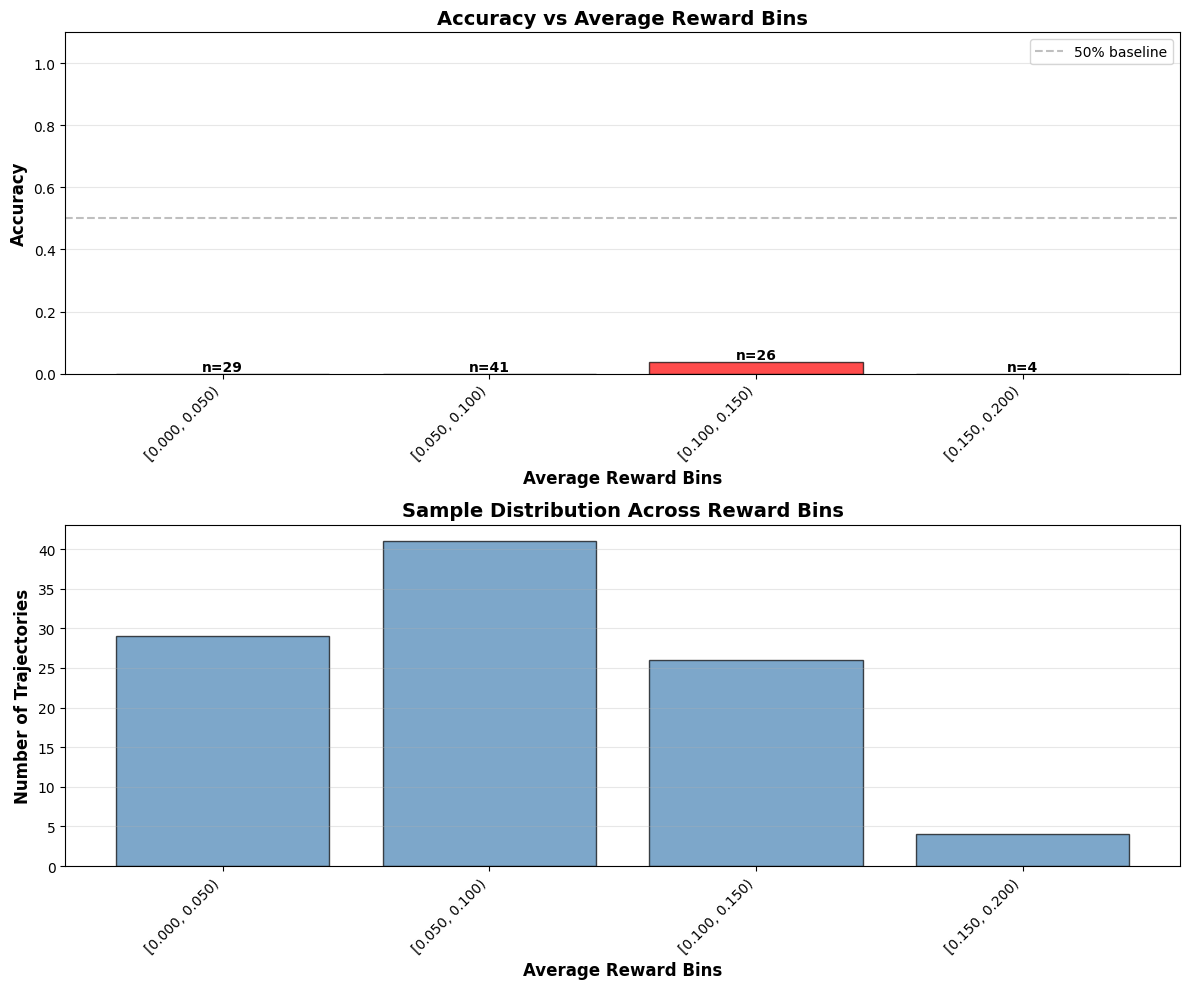


Detailed Bin Statistics:

Bin 1: [0.0000, 0.0500)
  Count: 29
  Accuracy: 0.00%
  Correct: 0/29

Bin 2: [0.0500, 0.1000)
  Count: 41
  Accuracy: 0.00%
  Correct: 0/41

Bin 3: [0.1000, 0.1500)
  Count: 26
  Accuracy: 3.85%
  Correct: 1/26

Bin 4: [0.1500, 0.2000)
  Count: 4
  Accuracy: 0.00%
  Correct: 0/4


In [16]:
import matplotlib.pyplot as plt

# Prepare data: filter out trajectories with None rewards
valid_data = [(trajectory_avg_rewards[i], correctness[i]) 
              for i in range(len(trajectory_avg_rewards)) 
              if trajectory_avg_rewards[i] is not None]

if len(valid_data) == 0:
    print("No valid data to plot")
else:
    rewards, correct_labels = zip(*valid_data)
    rewards = np.array(rewards)
    correct_labels = np.array(correct_labels)
    
    # Create bins for average rewards with fixed 0.05 intervals
    bin_width = 0.05
    min_reward = np.floor(rewards.min() / bin_width) * bin_width
    max_reward = np.ceil(rewards.max() / bin_width) * bin_width
    bin_edges = np.arange(min_reward, max_reward + bin_width, bin_width)
    n_bins = len(bin_edges) - 1
    
    # Calculate accuracy for each bin
    bin_accuracies = []
    bin_counts = []
    bin_centers = []
    
    for i in range(n_bins):
        # Find trajectories in this bin
        if i == n_bins - 1:
            # Last bin includes the upper edge
            mask = (rewards >= bin_edges[i]) & (rewards <= bin_edges[i+1])
        else:
            mask = (rewards >= bin_edges[i]) & (rewards < bin_edges[i+1])
        
        bin_correct = correct_labels[mask]
        
        if len(bin_correct) > 0:
            accuracy = bin_correct.mean()
            bin_accuracies.append(accuracy)
            bin_counts.append(len(bin_correct))
            bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
        else:
            bin_accuracies.append(0)
            bin_counts.append(0)
            bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Accuracy vs Average Reward Bins
    colors = ['red' if acc < 0.5 else 'orange' if acc < 0.75 else 'green' 
              for acc in bin_accuracies]
    bars = ax1.bar(range(n_bins), bin_accuracies, color=colors, alpha=0.7, edgecolor='black')
    
    # Add count labels on bars
    for i, (bar, count) in enumerate(zip(bars, bin_counts)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'n={count}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax1.set_xlabel('Average Reward Bins', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Accuracy vs Average Reward Bins', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(n_bins))
    ax1.set_xticklabels([f'[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})' 
                         for i in range(n_bins)], rotation=45, ha='right')
    ax1.set_ylim([0, 1.1])
    ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
    ax1.grid(axis='y', alpha=0.3)
    ax1.legend()
    
    # Plot 2: Sample count per bin
    ax2.bar(range(n_bins), bin_counts, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Average Reward Bins', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Trajectories', fontsize=12, fontweight='bold')
    ax2.set_title('Sample Distribution Across Reward Bins', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(n_bins))
    ax2.set_xticklabels([f'[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})' 
                         for i in range(n_bins)], rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\nDetailed Bin Statistics:")
    print("=" * 80)
    for i in range(n_bins):
        print(f"\nBin {i+1}: [{bin_edges[i]:.4f}, {bin_edges[i+1]:.4f})")
        print(f"  Count: {bin_counts[i]}")
        print(f"  Accuracy: {bin_accuracies[i]:.2%}")
        if bin_counts[i] > 0:
            print(f"  Correct: {int(bin_accuracies[i] * bin_counts[i])}/{bin_counts[i]}")


In [23]:
# Find the trajectory with second minimum average reward
valid_indices = [i for i, r in enumerate(trajectory_avg_rewards) if r is not None]
# Sort valid indices by average reward
sorted_indices = sorted(valid_indices, key=lambda i: trajectory_avg_rewards[i])
if len(sorted_indices) < 2:
    print("Not enough valid trajectories to find the second minimum.")
else:
    min_reward_idx = sorted_indices[40]

    min_reward_value = trajectory_avg_rewards[min_reward_idx]
    min_reward_steps = parsed_generations[min_reward_idx]
    min_reward_answer = predicted_answers[min_reward_idx]

    print(f"Second Minimum Reward Trajectory:")
    print(f"  Index: {min_reward_idx + 1}")
    print(f"  Average Reward: {min_reward_value:.4f}")
    print(f"  Number of Steps: {len(min_reward_steps)}")
    print(f"  Predicted Answer: {min_reward_answer}")
    print(f"  Correct: {'✓' if correctness[min_reward_idx] else '✗'}")
    print(f"\nSteps:")
    for i, step in enumerate(min_reward_steps):
        print(f"  Step {i+1}: {step[:1000]}...")
    print(f"\nStep-wise rewards: {[f'{r:.4f}' for r in all_trajectory_rewards[min_reward_idx]]}")


Second Minimum Reward Trajectory:
  Index: 75
  Average Reward: 0.0714
  Number of Steps: 12
  Predicted Answer: \frac{5472
  Correct: ✗

Steps:
  Step 1: To solve the problem, we start by analyzing the given information and the geometric properties of the points and quadrilateral....
  Step 2: First, let's place the points on the coordinate plane for convenience. Assume \( A = (0, 0) \), \( B = (28, 0) \), and \( C = (19, h) \) for some height \( h \)....
  Step 3: Given:
- \( AD = 4 \), \( DE = 16 \), and \( EB = 8 \)
- \( AF = 13 \), \( FG = 52 \), and \( GC = 26 \)...
  Step 4: We can determine the coordinates of points \( D \), \( E \), \( F \), and \( G \):
- \( D = (4, 0) \)
- \( E = (4 + 16, 0) = (20, 0) \)
- \( F = (13, 0) \)
- \( G = (13 + 52, h) = (65, h) \)...
  Step 5: Next, we find the coordinates of points \( M \) and \( N \):
- \( M \) is the reflection of \( D \) through \( F \). The midpoint of \( DF \) is \( \left( \frac{4 + 13}{2}, 0 \right) = (8.5, 0) \). Since \( 

In [48]:
tokenizer.decode(torch.tensor([198]))

'\n'

In [49]:
import torch.nn.functional as F

def optimize_tokens_for_max_reward(
    model, 
    tokenizer, 
    problem, 
    steps, 
    model_path, 
    device,
    num_new_tokens=10,
    num_iterations=100,
    learning_rate=0.1,
    temperature=1.0,
    entropy_weight_start=0.001,
    entropy_weight_end=0.1,
    entropy_schedule='linear'
):
    """
    Add random tokens at the end and optimize them to maximize reward.
    
    Args:
        model: The PRM model
        tokenizer: Tokenizer
        problem: Problem statement
        steps: List of reasoning steps
        model_path: Path to model for prepare_input
        device: Device to run on
        num_new_tokens: Number of tokens to add and optimize
        num_iterations: Number of optimization steps
        learning_rate: Learning rate for optimization
        temperature: Temperature for Gumbel-Softmax
        entropy_weight_start: Starting weight for entropy loss
        entropy_weight_end: Ending weight for entropy loss
        entropy_schedule: Schedule type ('linear', 'exponential', 'cosine')
    
    Returns:
        optimized_text: The optimized additional text
        reward_history: List of rewards during optimization
    """
    
    # Prepare the original input
    input_ids_orig, token_masks_orig = prepare_input(
        model_path, 
        problem=problem, 
        steps=steps, 
        tokenizer=tokenizer,
        device=device
    )
    # print(input_ids_orig[-1])
    # print(str(tokenizer.decode(input_ids_orig[-1])))
    # raise Exception("Stop here")
    
    # Get the actual embedding layer to determine vocab size
    if hasattr(model, 'pretrained_model'):
        embed_layer = model.pretrained_model.get_input_embeddings()
    else:
        embed_layer = model.get_input_embeddings()
    
    # Use the actual vocab size from the embedding layer
    vocab_size = embed_layer.weight.shape[0]
    
    # Initialize random logits for new tokens (these will be optimized)
    # Shape: (num_new_tokens, vocab_size)
    new_token_logits = torch.randn(
        num_new_tokens, vocab_size, 
        device=device, 
        requires_grad=True
    )
    
    optimizer = torch.optim.Adam([new_token_logits], lr=learning_rate)
    
    reward_history = []
    discrete_reward_history = []
    entropy_history = []
    entropy_weight_history = []
    best_reward = -float('inf')
    best_discrete_reward = -float('inf')
    best_tokens = None
    
    print(f"Starting optimization...")
    print(f"Original sequence length: {len(input_ids_orig)}")
    print(f"Adding {num_new_tokens} optimizable tokens")
    print(f"Entropy weight schedule: {entropy_schedule}")
    print(f"  Start weight: {entropy_weight_start:.4f}")
    print(f"  End weight: {entropy_weight_end:.4f}")
    print()
    
    for iteration in range(num_iterations):
        optimizer.zero_grad()
        
        # Calculate scheduled entropy weight
        progress = iteration / max(num_iterations - 1, 1)  # 0 to 1
        if entropy_schedule == 'linear':
            entropy_weight = entropy_weight_start + (entropy_weight_end - entropy_weight_start) * progress
        elif entropy_schedule == 'exponential':
            # Exponential growth from start to end
            entropy_weight = entropy_weight_start * (entropy_weight_end / entropy_weight_start) ** progress
        elif entropy_schedule == 'cosine':
            # Cosine annealing (smooth increase)
            entropy_weight = entropy_weight_start + (entropy_weight_end - entropy_weight_start) * (1 - np.cos(progress * np.pi)) / 2
        else:
            entropy_weight = entropy_weight_start  # Default to constant start weight
        
        entropy_weight_history.append(entropy_weight)
        
        # Use Gumbel-Softmax to get differentiable discrete sampling
        # This allows gradients to flow through the discrete token selection
        gumbel_softmax = F.gumbel_softmax(new_token_logits, tau=temperature, hard=False)
        
        # Calculate entropy of token distributions (measure of discreteness)
        # Lower entropy = more discrete/confident in token selection
        # Entropy = -sum(p * log(p))
        probs = F.softmax(new_token_logits, dim=-1)
        log_probs = F.log_softmax(new_token_logits, dim=-1)
        entropy_per_token = -(probs * log_probs).sum(dim=-1)  # Shape: (num_new_tokens,)
        avg_entropy = entropy_per_token.mean().item()
        entropy_history.append(avg_entropy)
        
        # Get embeddings for original tokens
        orig_embeddings = embed_layer(input_ids_orig)
        step_embeddings = embed_layer(torch.tensor([198], device=device))
        
        # Get embeddings for new tokens using weighted sum over vocabulary
        # Shape: (num_new_tokens, embedding_dim)
        # Cast gumbel_softmax to match embedding dtype
        gumbel_softmax = gumbel_softmax.to(embed_layer.weight.dtype)
        new_embeddings = torch.matmul(gumbel_softmax, embed_layer.weight)
        
        # Concatenate original and new embeddings
        # print(orig_embeddings[:-1].shape)
        # print(orig_embeddings[-1:].shape)
        # print(new_embeddings.shape)
        # raise Exception("Stop here")
        full_embeddings = torch.cat([orig_embeddings, new_embeddings, step_embeddings], dim=0)
        full_embeddings = full_embeddings.unsqueeze(0)  # Add batch dimension
        
        # Forward pass through model
        # The Skywork model returns (lm_logits, loss, value)
        with torch.set_grad_enabled(True):
            if hasattr(model, 'pretrained_model'):
                # For Skywork model, pass embeddings to the base model and get hidden states
                base_output = model.pretrained_model(
                    inputs_embeds=full_embeddings, 
                    output_hidden_states=True
                )
                last_hidden_state = base_output.hidden_states[-1]
                # Pass through value head to get reward logits
                reward_logits = model.v_head(last_hidden_state).squeeze(-1)
                # Get the reward for the last token
                reward_proxy = torch.sigmoid(reward_logits[0, -1])
            else:
                raise NotImplementedError("Only Skywork model is supported for now")
                outputs = model(inputs_embeds=full_embeddings)
                logits = outputs[-1] if isinstance(outputs, tuple) else outputs.logits
                # For other models that output token logits
                reward_proxy = torch.sigmoid(logits[0, -1, :])
        
        # Loss: negative reward (we want to maximize reward)
        # Using scheduled entropy weight that increases with iterations

        loss = -reward_proxy + entropy_weight * entropy_per_token.mean()
        
        # Backpropagation
        loss.backward()
        # Print the mean of the gradients for debugging/monitoring
        # grad_means = []
        # for param in optimizer.param_groups[0]['params']:
        #     if param.grad is not None:
        #         grad_means.append(param.grad.mean().item())
        # if grad_means:
        #     print(f"Mean of gradients: {sum(grad_means) / len(grad_means)}")
        # else:
        #     print("No gradients computed.")
        optimizer.step()
        
        # Track progress
        current_reward = reward_proxy.item()
        reward_history.append(current_reward)
        
        # Evaluate discrete token reward (without gradients)
        with torch.no_grad():
            # Get hard discrete tokens
            discrete_token_ids = torch.argmax(new_token_logits, dim=-1)
            
            # Get embeddings for discrete tokens
            discrete_embeddings = embed_layer(discrete_token_ids)
            
            # Concatenate with original embeddings
            full_discrete_embeddings = torch.cat([orig_embeddings, discrete_embeddings, step_embeddings], dim=0)
            full_discrete_embeddings = full_discrete_embeddings.unsqueeze(0)
            
            # Forward pass with discrete tokens
            if hasattr(model, 'pretrained_model'):
                base_output_discrete = model.pretrained_model(
                    inputs_embeds=full_discrete_embeddings,
                    output_hidden_states=True
                )
                last_hidden_state_discrete = base_output_discrete.hidden_states[-1]
                reward_logits_discrete = model.v_head(last_hidden_state_discrete).squeeze(-1)
                discrete_reward = torch.sigmoid(reward_logits_discrete[0, -1]).item()
            else:
                raise NotImplementedError("Only Skywork model is supported for now")
                outputs_discrete = model(inputs_embeds=full_discrete_embeddings)
                logits_discrete = outputs_discrete[-1] if isinstance(outputs_discrete, tuple) else outputs_discrete.logits
                discrete_reward = torch.sigmoid(logits_discrete[0, -1, :]).item()
            
            discrete_reward_history.append(discrete_reward)
        
        if current_reward > best_reward:
            best_reward = current_reward
            # Get hard token ids for the best configuration
            
        
        if discrete_reward > best_discrete_reward:
            best_discrete_reward = discrete_reward
            best_token_ids = torch.argmax(new_token_logits, dim=-1)
            best_tokens = best_token_ids.detach().cpu().tolist()
        
        if (iteration + 1) % 10 == 0:
            # Decode current best tokens
            current_tokens = torch.argmax(gumbel_softmax, dim=-1).detach().cpu().tolist()
            decoded_text = tokenizer.decode(current_tokens)
            print(f"Iteration {iteration + 1}/{num_iterations}")
            print(f"  Soft Reward (Gumbel): {current_reward:.4f} | Best: {best_reward:.4f}")
            print(f"  Discrete Reward (Hard): {discrete_reward:.4f} | Best: {best_discrete_reward:.4f}")
            print(f"  Reward Gap (Soft-Hard): {current_reward - discrete_reward:+.4f}")
            print(f"  Entropy Weight: {entropy_weight:.6f}")
            print(f"  Avg Entropy: {avg_entropy:.4f} (max possible: {np.log(vocab_size):.4f})")
            print(f"  Current Tokens: {decoded_text[:100]}")
            print()
    
    # Decode the best tokens found
    optimized_text = tokenizer.decode(best_tokens)
    
    print(f"\nOptimization Complete!")
    print(f"\nReward Metrics:")
    print(f"  Best Soft Reward (Gumbel): {best_reward:.4f}")
    print(f"  Best Discrete Reward (Hard): {best_discrete_reward:.4f}")
    print(f"  Final Soft Reward: {reward_history[-1]:.4f}")
    print(f"  Final Discrete Reward: {discrete_reward_history[-1]:.4f}")
    print(f"  Final Reward Gap: {reward_history[-1] - discrete_reward_history[-1]:+.4f}")
    print(f"\nEntropy Metrics:")
    print(f"  Final Avg Entropy: {entropy_history[-1]:.4f}")
    print(f"  Initial Avg Entropy: {entropy_history[0]:.4f}")
    print(f"  Entropy Reduction: {entropy_history[0] - entropy_history[-1]:.4f}")
    print(f"\nWeight Schedule:")
    print(f"  Final Entropy Weight: {entropy_weight_history[-1]:.6f}")
    print(f"  Initial Entropy Weight: {entropy_weight_history[0]:.6f}")
    print(f"\nOptimized Text: {optimized_text}")
    
    return optimized_text, reward_history, discrete_reward_history, entropy_history, entropy_weight_history, best_tokens


In [53]:
# Run the optimization
optimized_text, reward_history, discrete_reward_history, entropy_history, entropy_weight_history, optimized_tokens = optimize_tokens_for_max_reward(
    model=model,
    tokenizer=tokenizer,
    problem=data["problem"],
    steps=min_reward_steps,
    model_path=SKYWORK_MODEL_PATH,
    device=torch.device("cuda:0"),
    num_new_tokens=100,  # Number of tokens to optimize
    num_iterations=2000,  # Number of optimization steps
    learning_rate=1e-1,   # Learning rate
    temperature=1,     # Temperature for Gumbel-Softmax (lower = more discrete)
    entropy_weight_start=0.0001,  # Starting entropy weight
    entropy_weight_end=0.1,      # Ending entropy weight
    entropy_schedule='cosine'    # Schedule type: 'linear', 'exponential', or 'cosine'
)


Starting optimization...
Original sequence length: 1666
Adding 100 optimizable tokens
Entropy weight schedule: cosine
  Start weight: 0.0001
  End weight: 0.1000

Iteration 10/2000
  Soft Reward (Gumbel): 0.0505 | Best: 0.0527
  Discrete Reward (Hard): 0.0682 | Best: 0.0714
  Reward Gap (Soft-Hard): -0.0177
  Entropy Weight: 0.000105
  Avg Entropy: 11.4137 (max possible: 11.9312)
  Current Tokens: _readingaviestค้น exig中国政府.apiUrlLCD Upsوسط非常晔ｖrtsutr Curry cvsфт Revelornings-sm thrustぺ时时 dominate

Iteration 20/2000
  Soft Reward (Gumbel): 0.0599 | Best: 0.0599
  Discrete Reward (Hard): 0.0685 | Best: 0.0743
  Reward Gap (Soft-Hard): -0.0086
  Entropy Weight: 0.000122
  Avg Entropy: 11.3734 (max possible: 11.9312)
  Current Tokens:  curb meleedurationنهaslChar submodule了过来 bundleضلירות.Perform surroundings_pct entrepreneurialmulti

Iteration 30/2000
  Soft Reward (Gumbel): 0.0657 | Best: 0.0695
  Discrete Reward (Hard): 0.0768 | Best: 0.0807
  Reward Gap (Soft-Hard): -0.0110
  Entropy W

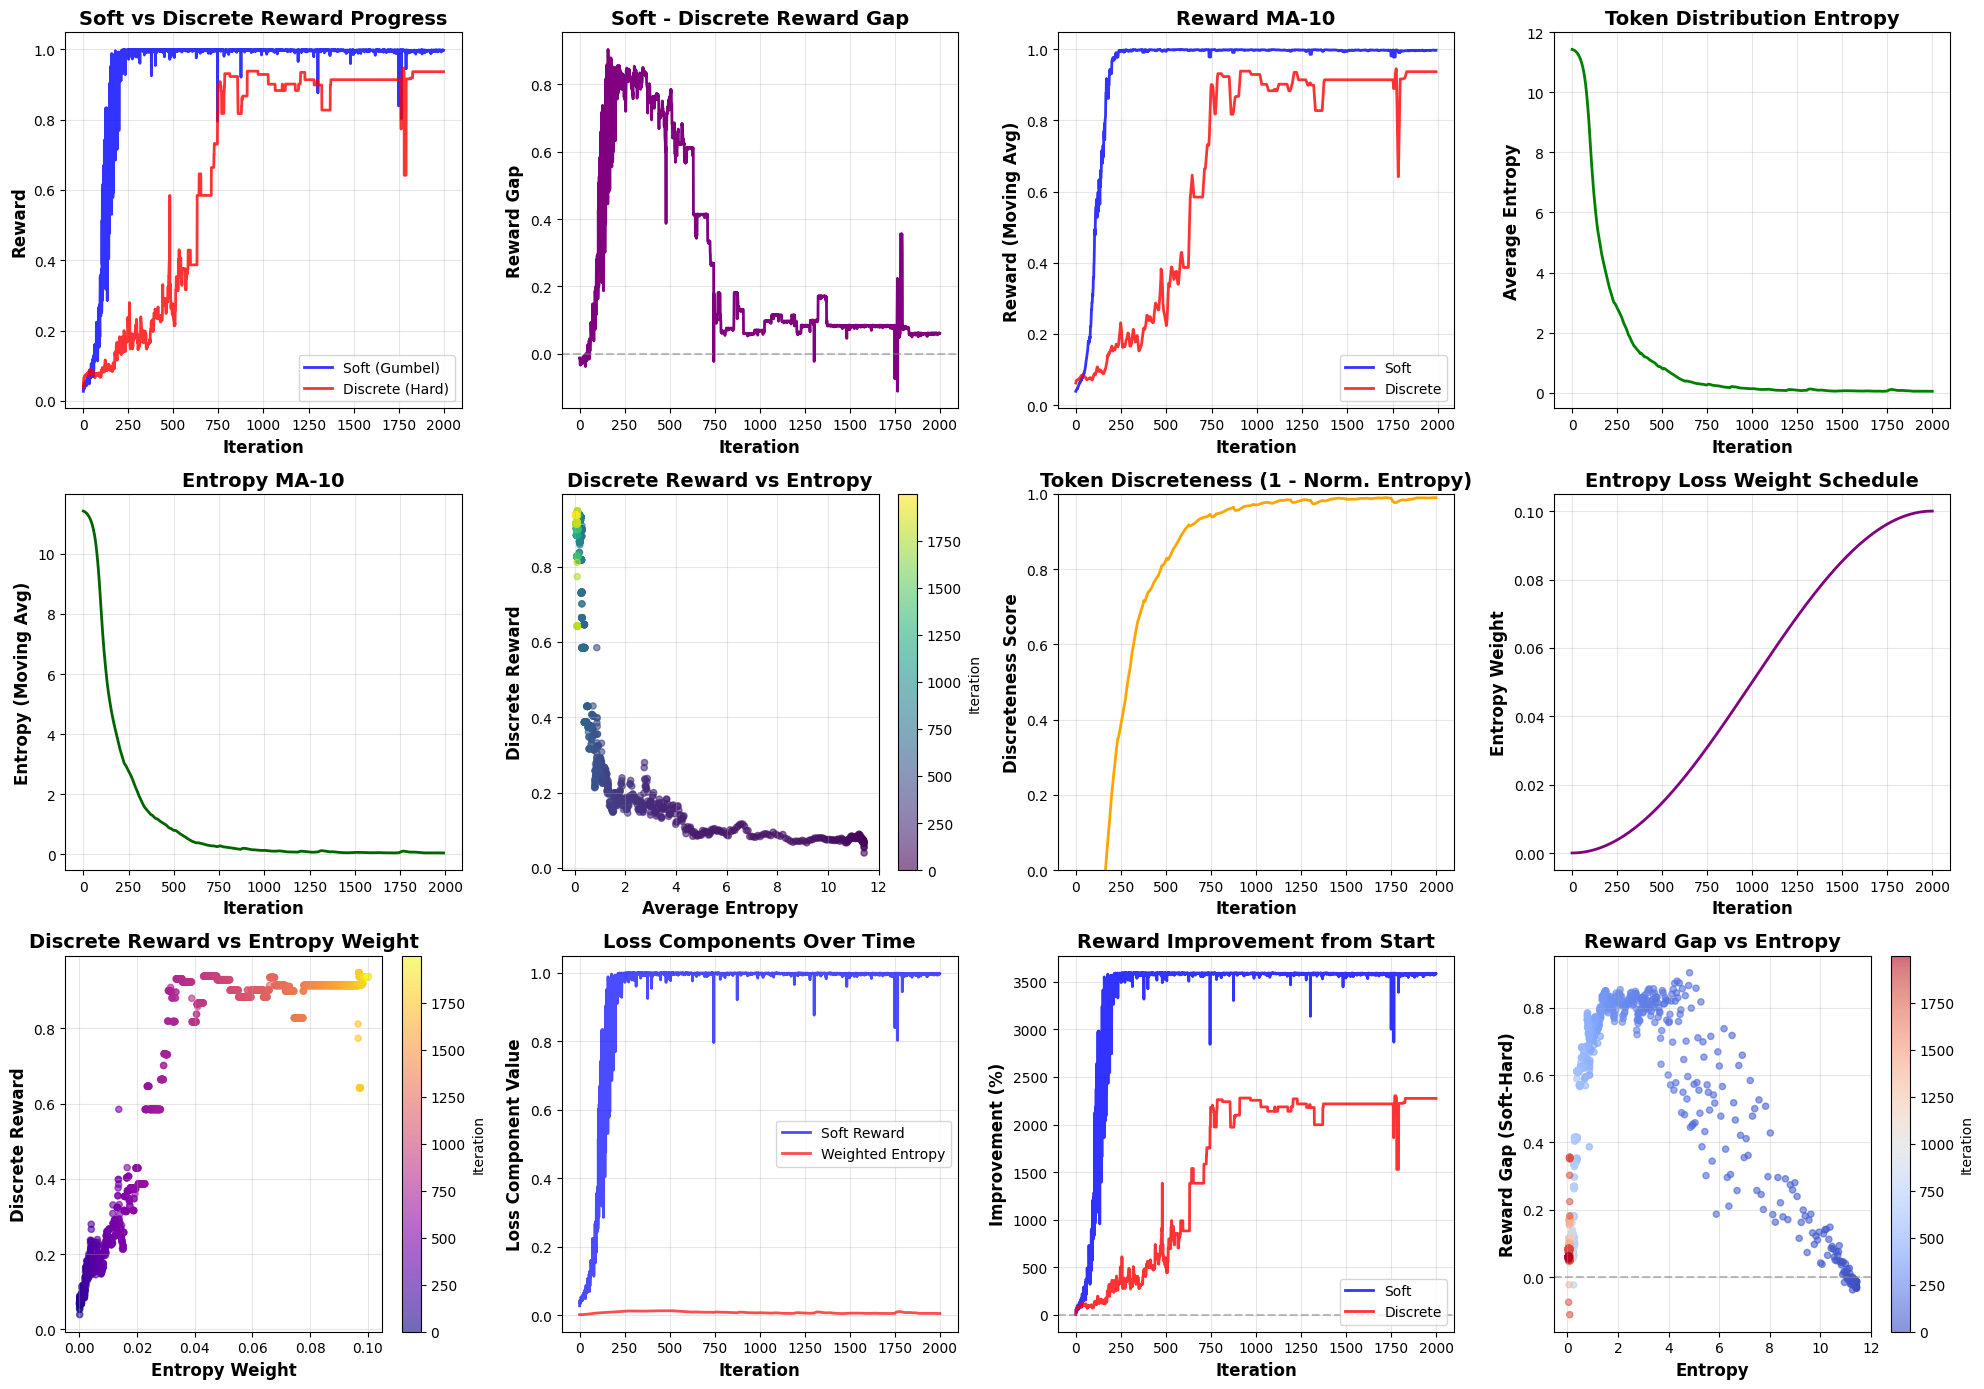


Optimization Summary:

Soft Reward Metrics (Gumbel-Softmax):
  Initial: 0.0271
  Final: 0.9972
  Best: 0.9999
  Improvement: 0.9729
  Improvement %: 3596.29%

Discrete Reward Metrics (Hard Tokens):
  Initial: 0.0394
  Final: 0.9366
  Best: 0.9473
  Improvement: 0.9079
  Improvement %: 2301.87%

Reward Gap Analysis (Soft - Discrete):
  Initial Gap: -0.0124
  Final Gap: +0.0606
  Average Gap: +0.2679
  Gap Change: +0.0730
  Max Gap: +0.9038 (iter 159)
  Min Gap: -0.1113 (iter 1766)

Entropy Metrics:
  Initial Avg Entropy: 11.4315
  Final Avg Entropy: 0.0449
  Entropy Reduction: 11.3865
  Max Possible Entropy: 4.6052
  Final Discreteness: 99.02%

Entropy Weight Schedule:
  Initial Weight: 0.000100
  Final Weight: 0.100000
  Weight Increase: 0.099900
  Weight Multiplier: 1000.00x

Loss Component Analysis:
  Initial Weighted Entropy: 0.001143
  Final Weighted Entropy: 0.004494
  Despite 1000.0x weight increase, entropy decreased by 99.6%


In [54]:
# Plot the optimization progress
plt.figure(figsize=(20, 14))

# Plot 1: Soft vs Discrete Reward Comparison
plt.subplot(3, 4, 1)
plt.plot(reward_history, linewidth=2, color='blue', label='Soft (Gumbel)', alpha=0.8)
plt.plot(discrete_reward_history, linewidth=2, color='red', label='Discrete (Hard)', alpha=0.8)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Reward', fontsize=12, fontweight='bold')
plt.title('Soft vs Discrete Reward Progress', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Reward Gap (Soft - Discrete)
plt.subplot(3, 4, 2)
reward_gap = np.array(reward_history) - np.array(discrete_reward_history)
plt.plot(reward_gap, linewidth=2, color='purple')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Reward Gap', fontsize=12, fontweight='bold')
plt.title('Soft - Discrete Reward Gap', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 3: Reward moving average 
plt.subplot(3, 4, 3)
window_size = 10
if len(reward_history) >= window_size:
    soft_ma = np.convolve(reward_history, np.ones(window_size)/window_size, mode='valid')
    discrete_ma = np.convolve(discrete_reward_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(soft_ma, linewidth=2, color='blue', label='Soft', alpha=0.8)
    plt.plot(discrete_ma, linewidth=2, color='red', label='Discrete', alpha=0.8)
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Reward (Moving Avg)', fontsize=12, fontweight='bold')
    plt.title(f'Reward MA-{window_size}', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

# Plot 4: Entropy progress
plt.subplot(3, 4, 4)
plt.plot(entropy_history, linewidth=2, color='green')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Average Entropy', fontsize=12, fontweight='bold')
plt.title('Token Distribution Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 5: Entropy moving average
plt.subplot(3, 4, 5)
if len(entropy_history) >= window_size:
    entropy_ma = np.convolve(entropy_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(entropy_ma, linewidth=2, color='darkgreen')
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Entropy (Moving Avg)', fontsize=12, fontweight='bold')
    plt.title(f'Entropy MA-{window_size}', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)

# Plot 6: Discrete Reward vs Entropy scatter
plt.subplot(3, 4, 6)
scatter = plt.scatter(entropy_history, discrete_reward_history, c=range(len(discrete_reward_history)), 
                     cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Iteration')
plt.xlabel('Average Entropy', fontsize=12, fontweight='bold')
plt.ylabel('Discrete Reward', fontsize=12, fontweight='bold')
plt.title('Discrete Reward vs Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 7: Discreteness metric (inverse of normalized entropy)
plt.subplot(3, 4, 7)
# Normalize entropy by max possible (uniform distribution)
max_entropy = np.log(len(optimized_tokens))  # For discrete uniform distribution
normalized_entropy = np.array(entropy_history) / max_entropy
discreteness = 1 - normalized_entropy  # Higher = more discrete
plt.plot(discreteness, linewidth=2, color='orange')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Discreteness Score', fontsize=12, fontweight='bold')
plt.title('Token Discreteness (1 - Norm. Entropy)', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(alpha=0.3)

# Plot 8: Entropy Weight Schedule
plt.subplot(3, 4, 8)
plt.plot(entropy_weight_history, linewidth=2, color='purple')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Entropy Weight', fontsize=12, fontweight='bold')
plt.title('Entropy Loss Weight Schedule', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 9: Entropy Weight vs Discrete Reward
plt.subplot(3, 4, 9)
scatter2 = plt.scatter(entropy_weight_history, discrete_reward_history, c=range(len(discrete_reward_history)),
                      cmap='plasma', alpha=0.6, s=20)
plt.colorbar(scatter2, label='Iteration')
plt.xlabel('Entropy Weight', fontsize=12, fontweight='bold')
plt.ylabel('Discrete Reward', fontsize=12, fontweight='bold')
plt.title('Discrete Reward vs Entropy Weight', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 10: Effective Loss Components Over Time
plt.subplot(3, 4, 10)
reward_component = np.array(reward_history)
entropy_component = np.array(entropy_history) * np.array(entropy_weight_history)
plt.plot(reward_component, linewidth=2, color='blue', label='Soft Reward', alpha=0.7)
plt.plot(entropy_component, linewidth=2, color='red', label='Weighted Entropy', alpha=0.7)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Loss Component Value', fontsize=12, fontweight='bold')
plt.title('Loss Components Over Time', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 11: Reward Improvement (relative to initial)
plt.subplot(3, 4, 11)
soft_improvement = (np.array(reward_history) - reward_history[0]) / max(abs(reward_history[0]), 1e-6) * 100
discrete_improvement = (np.array(discrete_reward_history) - discrete_reward_history[0]) / max(abs(discrete_reward_history[0]), 1e-6) * 100
plt.plot(soft_improvement, linewidth=2, color='blue', label='Soft', alpha=0.8)
plt.plot(discrete_improvement, linewidth=2, color='red', label='Discrete', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Improvement (%)', fontsize=12, fontweight='bold')
plt.title('Reward Improvement from Start', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 12: Correlation: Reward Gap vs Entropy
plt.subplot(3, 4, 12)
plt.scatter(entropy_history, reward_gap, c=range(len(reward_gap)), cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(label='Iteration')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Entropy', fontsize=12, fontweight='bold')
plt.ylabel('Reward Gap (Soft-Hard)', fontsize=12, fontweight='bold')
plt.title('Reward Gap vs Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimization Summary:")
print(f"=" * 70)
print(f"\nSoft Reward Metrics (Gumbel-Softmax):")
print(f"  Initial: {reward_history[0]:.4f}")
print(f"  Final: {reward_history[-1]:.4f}")
print(f"  Best: {max(reward_history):.4f}")
print(f"  Improvement: {max(reward_history) - reward_history[0]:.4f}")
print(f"  Improvement %: {(max(reward_history) - reward_history[0]) / max(abs(reward_history[0]), 1e-6) * 100:.2f}%")

print(f"\nDiscrete Reward Metrics (Hard Tokens):")
print(f"  Initial: {discrete_reward_history[0]:.4f}")
print(f"  Final: {discrete_reward_history[-1]:.4f}")
print(f"  Best: {max(discrete_reward_history):.4f}")
print(f"  Improvement: {max(discrete_reward_history) - discrete_reward_history[0]:.4f}")
print(f"  Improvement %: {(max(discrete_reward_history) - discrete_reward_history[0]) / max(abs(discrete_reward_history[0]), 1e-6) * 100:.2f}%")

print(f"\nReward Gap Analysis (Soft - Discrete):")
initial_gap = reward_history[0] - discrete_reward_history[0]
final_gap = reward_history[-1] - discrete_reward_history[-1]
avg_gap = np.mean(reward_gap)
print(f"  Initial Gap: {initial_gap:+.4f}")
print(f"  Final Gap: {final_gap:+.4f}")
print(f"  Average Gap: {avg_gap:+.4f}")
print(f"  Gap Change: {final_gap - initial_gap:+.4f}")
print(f"  Max Gap: {max(reward_gap):+.4f} (iter {np.argmax(reward_gap)+1})")
print(f"  Min Gap: {min(reward_gap):+.4f} (iter {np.argmin(reward_gap)+1})")

print(f"\nEntropy Metrics:")
print(f"  Initial Avg Entropy: {entropy_history[0]:.4f}")
print(f"  Final Avg Entropy: {entropy_history[-1]:.4f}")
print(f"  Entropy Reduction: {entropy_history[0] - entropy_history[-1]:.4f}")
print(f"  Max Possible Entropy: {np.log(len(optimized_tokens)):.4f}")
print(f"  Final Discreteness: {(1 - entropy_history[-1]/np.log(len(optimized_tokens)))*100:.2f}%")

print(f"\nEntropy Weight Schedule:")
print(f"  Initial Weight: {entropy_weight_history[0]:.6f}")
print(f"  Final Weight: {entropy_weight_history[-1]:.6f}")
print(f"  Weight Increase: {entropy_weight_history[-1] - entropy_weight_history[0]:.6f}")
print(f"  Weight Multiplier: {entropy_weight_history[-1] / max(entropy_weight_history[0], 1e-9):.2f}x")

print(f"\nLoss Component Analysis:")
print(f"  Initial Weighted Entropy: {entropy_history[0] * entropy_weight_history[0]:.6f}")
print(f"  Final Weighted Entropy: {entropy_history[-1] * entropy_weight_history[-1]:.6f}")
print(f"  Despite {entropy_weight_history[-1]/entropy_weight_history[0]:.1f}x weight increase, entropy decreased by {(1-entropy_history[-1]/entropy_history[0])*100:.1f}%")


In [55]:
# Additional analysis on discrete vs soft rewards
print(f"\n{'=' * 70}")
print(f"DISCRETE vs SOFT REWARD ANALYSIS")
print(f"{'=' * 70}")

print(f"\nKey Metrics:")
soft_improvement = (max(reward_history) - reward_history[0]) / max(abs(reward_history[0]), 1e-6) * 100
discrete_improvement = (max(discrete_reward_history) - discrete_reward_history[0]) / max(abs(discrete_reward_history[0]), 1e-6) * 100

print(f"  Soft (Gumbel) Reward Improvement: {soft_improvement:.1f}%")
print(f"  Discrete (Hard) Reward Improvement: {discrete_improvement:.1f}%")

print(f"\nReward Gap Statistics:")
reward_gap = np.array(reward_history) - np.array(discrete_reward_history)
print(f"  Mean Gap: {np.mean(reward_gap):.4f}")
print(f"  Std Gap: {np.std(reward_gap):.4f}")
print(f"  Gap Correlation with Entropy: {np.corrcoef(entropy_history, reward_gap)[0,1]:.4f}")

print(f"\nOptimization Effectiveness:")
if discrete_improvement > 0:
    print(f"  ✓ Discrete rewards ARE improving ({discrete_improvement:.1f}%)")
    print(f"  ✓ Optimization successfully transfers to discrete tokens!")
    if discrete_improvement > 0.5 * soft_improvement:
        print(f"  ✓ Strong transfer: {discrete_improvement/soft_improvement*100:.1f}% of soft improvement")
    else:
        print(f"  ⚠ Moderate transfer: {discrete_improvement/soft_improvement*100:.1f}% of soft improvement")
else:
    print(f"  ⚠ Discrete rewards NOT improving")
    print(f"  ⚠ May be exploiting soft approximation without real discrete gains")

print(f"\nEntropy Schedule Effectiveness:")
entropy_reduction_pct = (1 - entropy_history[-1]/entropy_history[0]) * 100
print(f"  Entropy reduced by {entropy_reduction_pct:.1f}% despite {entropy_weight_history[-1]/entropy_weight_history[0]:.1f}x weight increase")
print(f"  This indicates tokens are becoming more discrete (good for discrete reward)")

print(f"{'=' * 70}")



DISCRETE vs SOFT REWARD ANALYSIS

Key Metrics:
  Soft (Gumbel) Reward Improvement: 3596.3%
  Discrete (Hard) Reward Improvement: 2301.9%

Reward Gap Statistics:
  Mean Gap: 0.2679
  Std Gap: 0.2839
  Gap Correlation with Entropy: 0.1437

Optimization Effectiveness:
  ✓ Discrete rewards ARE improving (2301.9%)
  ✓ Optimization successfully transfers to discrete tokens!
  ✓ Strong transfer: 64.0% of soft improvement

Entropy Schedule Effectiveness:
  Entropy reduced by 99.6% despite 1000.0x weight increase
  This indicates tokens are becoming more discrete (good for discrete reward)


In [162]:
min_reward_steps[-1]

'Since none of the negative divisors of 56 yield a valid \\( b \\) such that \\( b > 9 \\), there are no integer bases \\( b > 9 \\) for which \\( 17_b \\) is a divisor of \\( 97_b \\). Therefore, the sum of all such integer bases is:\n\\[\n\\boxed{0}\n\\]'

In [161]:
optimized_text

'"}\n\n Sor tenemos nämlich DaCOOKIE\ttr godt reckless primera'

In [160]:
tokenizer.encode(min_reward_steps.copy()[-1] +optimized_text)

[12549,
 6857,
 315,
 279,
 8225,
 3429,
 41214,
 315,
 220,
 20,
 21,
 7540,
 264,
 2697,
 17767,
 293,
 1124,
 8,
 1741,
 429,
 17767,
 293,
 861,
 220,
 24,
 1124,
 701,
 1052,
 525,
 902,
 7546,
 23092,
 17767,
 293,
 861,
 220,
 24,
 1124,
 8,
 369,
 892,
 17767,
 220,
 16,
 22,
 880,
 1124,
 8,
 374,
 264,
 49109,
 315,
 17767,
 220,
 24,
 22,
 880,
 1124,
 568,
 15277,
 11,
 279,
 2629,
 315,
 678,
 1741,
 7546,
 23092,
 374,
 510,
 59,
 9640,
 59,
 79075,
 90,
 15,
 532,
 59,
 19177,
 630,
 29531,
 70448,
 143525,
 14235,
 44796,
 25583,
 80223,
 53217,
 43669]

In [57]:
optimized_steps = min_reward_steps.copy()
# optimized_steps[-1] = optimized_steps[-1] +'\n' +optimized_text
input_ids_orig, token_masks_orig = prepare_input(
        SKYWORK_MODEL_PATH, 
        problem=data["problem"], 
        steps=optimized_steps, 
        tokenizer=tokenizer,
        device=torch.device("cuda:0")
    )
input_ids_orig = torch.cat([input_ids_orig,torch.tensor(optimized_tokens,device=torch.device("cuda:0")), torch.tensor([198],device=torch.device("cuda:0"))],dim=0)
embed_layer = model.pretrained_model.get_input_embeddings()
orig_embeddings = embed_layer(input_ids_orig).unsqueeze(0)
base_output = model.pretrained_model(
                    inputs_embeds=orig_embeddings, 
                    output_hidden_states=True
                )
last_hidden_state = base_output.hidden_states[-1]
# Pass through value head to get reward logits
reward_logits = model.v_head(last_hidden_state).squeeze(-1)
# Get the reward for the last token
reward_proxy = torch.sigmoid(reward_logits[0, -1])
print(reward_proxy)

tensor(0.9473, device='cuda:0', grad_fn=<SigmoidBackward0>)


In [153]:
tokenizer.decode(input_ids_orig[-10:])

'[\n\\boxed{0}\n\\]吉林省\n'

In [117]:
torch.cat([input_ids_orig,torch.tensor(tokenizer.encode(optimized_text),device=torch.device("cuda:0"))],dim=0)

tensor([151644,   9885,    279,  ...,  73638, 143578,  44503], device='cuda:0')

In [118]:
token_masks_orig.sum()

tensor(10, device='cuda:0')

In [119]:
reward_logits.shape

torch.Size([1, 1232])

In [122]:
torch.sigmoid(reward_logits).squeeze()

tensor([0.3489, 0.4598, 0.2812,  ..., 0.1817, 0.5119, 0.3981], device='cuda:0',
       grad_fn=<SqueezeBackward0>)

In [65]:
orig_embeddings.shape

torch.Size([1, 781, 1536])

In [148]:
tokenizer.encode(optimized_text)

[110904]

In [146]:
# Now evaluate the optimized trajectory with the actual PRM reward function
# Create a new step by appending the optimized text to the last step
optimized_steps = min_reward_steps.copy()
optimized_steps[-1] = optimized_steps[-1] + optimized_text

# optimized_steps.append(optimized_text)

print(f"Original trajectory steps: {len(min_reward_steps)}")
print(f"Optimized trajectory steps: {len(optimized_steps)}")
print(f"\nNew optimized step:")
print(f"  {optimized_text}")
print()

# Calculate rewards for the optimized trajectory
optimized_rewards = calculate_stepwise_rewards_for_trajectory(
    model=model,
    tokenizer=tokenizer,
    problem=data["problem"],
    steps=optimized_steps,
    model_path=SKYWORK_MODEL_PATH,
    device=torch.device("cuda:0")
)

optimized_avg_reward = np.mean(optimized_rewards) if optimized_rewards else 0

print(f"\nReward Comparison:")
print(f"  Original Average Reward: {min_reward_value:.4f}")
print(f"  Original Step Rewards: {[f'{r:.4f}' for r in all_trajectory_rewards[min_reward_idx]]}")
print()
print(f"  Optimized Average Reward: {optimized_avg_reward:.4f}")
print(f"  Optimized Step Rewards: {[f'{r:.4f}' for r in optimized_rewards]}")
print()
print(f"  Improvement: {optimized_avg_reward - min_reward_value:.4f}")
print(f"  Improvement %: {(optimized_avg_reward - min_reward_value) / max(abs(min_reward_value), 1e-6) * 100:.2f}%")


Original trajectory steps: 10
Optimized trajectory steps: 10

New optimized step:
  吉林省


Reward Comparison:
  Original Average Reward: 0.2897
  Original Step Rewards: ['0.4929', '0.4244', '0.3741', '0.3600', '0.3226', '0.2696', '0.2344', '0.1931', '0.1471', '0.0785']

  Optimized Average Reward: 0.2915
  Optimized Step Rewards: ['0.4929', '0.4244', '0.3741', '0.3600', '0.3226', '0.2696', '0.2344', '0.1931', '0.1471', '0.0972']

  Improvement: 0.0019
  Improvement %: 0.64%


In [33]:
# Analyze correlation between average rewards and correctness
print("Trajectory Analysis: Rewards vs Correctness")
print("=" * 70)

for i in range(len(generated_answers)):
    avg_reward = trajectory_avg_rewards[i]
    is_correct = correctness[i]
    predicted_ans = predicted_answers[i]
    num_steps = len(parsed_generations[i])
    
    print(f"\nGeneration {i+1}:")
    print(f"  Predicted Answer: {predicted_ans}")
    print(f"  Correct: {'✓' if is_correct else '✗'}")
    print(f"  Number of Steps: {num_steps}")
    if avg_reward is not None:
        print(f"  Average Reward: {avg_reward:.4f}")
        if all_trajectory_rewards[i]:
            print(f"  Min Step Reward: {min(all_trajectory_rewards[i]):.4f}")
            print(f"  Max Step Reward: {max(all_trajectory_rewards[i]):.4f}")
    else:
        print(f"  Average Reward: N/A")

# Separate correct and incorrect trajectories
correct_rewards = [trajectory_avg_rewards[i] for i in range(len(correctness)) 
                   if correctness[i] == 1 and trajectory_avg_rewards[i] is not None]
incorrect_rewards = [trajectory_avg_rewards[i] for i in range(len(correctness)) 
                     if correctness[i] == 0 and trajectory_avg_rewards[i] is not None]

print("\n" + "=" * 70)
print("Comparison: Correct vs Incorrect Trajectories")
print("-" * 70)

if correct_rewards:
    print(f"Correct Trajectories (n={len(correct_rewards)}):")
    print(f"  Mean Average Reward: {np.mean(correct_rewards):.4f}")
    print(f"  Std Average Reward: {np.std(correct_rewards):.4f}")
else:
    print("Correct Trajectories: None")

if incorrect_rewards:
    print(f"\nIncorrect Trajectories (n={len(incorrect_rewards)}):")
    print(f"  Mean Average Reward: {np.mean(incorrect_rewards):.4f}")
    print(f"  Std Average Reward: {np.std(incorrect_rewards):.4f}")
else:
    print("\nIncorrect Trajectories: None")


Trajectory Analysis: Rewards vs Correctness

Generation 1:
  Predicted Answer: 21
  Correct: ✓
  Number of Steps: 7
  Average Reward: 0.6563
  Min Step Reward: 0.4501
  Max Step Reward: 0.9278

Generation 2:
  Predicted Answer: 17
  Correct: ✗
  Number of Steps: 7
  Average Reward: 0.6722
  Min Step Reward: 0.4396
  Max Step Reward: 0.9448

Generation 3:
  Predicted Answer: 17
  Correct: ✗
  Number of Steps: 7
  Average Reward: 0.5684
  Min Step Reward: 0.3855
  Max Step Reward: 0.9224

Generation 4:
  Predicted Answer: 17
  Correct: ✗
  Number of Steps: 7
  Average Reward: 0.5249
  Min Step Reward: 0.2051
  Max Step Reward: 0.9528

Generation 5:
  Predicted Answer: 21
  Correct: ✓
  Number of Steps: 7
  Average Reward: 0.5385
  Min Step Reward: 0.3343
  Max Step Reward: 0.9314

Generation 6:
  Predicted Answer: 21
  Correct: ✓
  Number of Steps: 7
  Average Reward: 0.6730
  Min Step Reward: 0.4924
  Max Step Reward: 0.9327

Generation 7:
  Predicted Answer: 21
  Correct: ✓
  Number of